<a href="https://colab.research.google.com/github/Stephanie-hezekiah/Electronic-Sales-Analysis/blob/main/DKIPPI_PROJECT.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [8]:
import pandas as pd
import random
import string

# Define lists for realistic Nigerian synthetic data generation
first_names_m = ["Abubakar", "Chidi", "Olumide", "Emeka", "Tunde", "Ibrahim", "Nnamdi", "Femi", "Sani", "Kayode", "Uche", "Musa", "Babatunde", "Chinedu", "Segun"]
first_names_f = ["Amina", "Chiamaka", "Oluchi", "Zainab", "Titilayo", "Ifunanya", "Nneka", "Bisi", "Fatima", "Folake", "Ada", "Khadijah", "Chinelo", "Yewande", "Amara"]
last_names = ["Adeyemi", "Okonkwo", "Bello", "Ojo", "Eze", "Balogun", "Danjuma", "Obi", "Nwosu", "Lawal", "Agboola", "Okeke", "Usman", "Adebayo", "Igwe"]
states = ["Lagos", "Kano", "Oyo", "Rivers", "Anambra", "Enugu", "Kaduna", "Ogun", "Delta", "Edo", "Abia", "Imo", "Plateau", "Kwara", "Osun"]
streets = ["Ajayi Road", "Akintola Street", "Nnamdi Azikwe Avenue", "Bompai Road", "GRA Phase 2", "Old Aba Road", "Independence Layout", "Oke-Ado Road", "Herbert Macaulay Way", "Adetokunbo Ademola Street"]
cities = ["Ikeja", "Ibadan", "Awka", "Kano", "Minna", "Port Harcourt", "Enugu", "Aba", "Osogbo", "Victoria Island"]
email_domains = ["gmail.com", "yahoo.com", "outlook.com", "hotmail.com"]

def generate_synthetic_data(num_records=1000):
    data = []
    for i in range(1, num_records + 1):
        gender = random.choice(["M", "F"])
        first_name = random.choice(first_names_m if gender == "M" else first_names_f)
        last_name = random.choice(last_names)
        full_name = f"{first_name} {last_name}"

        # Format the email
        email = f"{first_name.lower()}.{last_name.lower()}{random.randint(1, 999)}@{random.choice(email_domains)}"

        # NIN (11 digits as per standard, though the sample CSV had 12, the proposal says 11)
        # Proposal Source 30: "detect the 11-digit patterns of Nigerian NINs and BVNs"
        nin = "".join([str(random.randint(0, 9)) for _ in range(11)])

        # BVN (11 digits)
        bvn = "".join([str(random.randint(0, 9)) for _ in range(11)])

        # Phone Number (Nigerian format: 0 + 70/80/81/90/91 + 8 digits)
        prefix = random.choice(["070", "080", "081", "090", "091"])
        phone = prefix + "".join([str(random.randint(0, 9)) for _ in range(8)])

        address = f"{random.randint(1, 100)}, {random.choice(streets)}, {random.choice(cities)}, {random.choice(states)} State"

        data.append({
            "S/N": i,
            "NAME": full_name,
            "SEX": gender,
            "ADDRESS": address,
            "PHONE NUMBER": phone,
            "BVN": bvn,
            "NIN": nin,
            "EMAIL ADDRESS": email
        })
    return pd.DataFrame(data)

# Generate 1050 records to exceed the "1,000+" requirement in Objective 3
df_synthetic = generate_synthetic_data(1050)

# Save the file
output_file = "DKIPPI_Synthetic_Dataset_1050.csv"
df_synthetic.to_csv(output_file, index=False)

# Display head to confirm
print(df_synthetic.head())
print(f"\nGenerated {len(df_synthetic)} records.")

   S/N           NAME SEX                                          ADDRESS  \
0    1   Abubakar Ojo   M  54, Adetokunbo Ademola Street, Ikeja, Edo State   
1    2     Sani Bello   M              41, Oke-Ado Road, Kano, Lagos State   
2    3    Amina Usman   F           71, Akintola Street, Osogbo, Edo State   
3    4      Emeka Eze   M             61, GRA Phase 2, Ibadan, Delta State   
4    5  Chinelo Okeke   F          75, Akintola Street, Kano, Kaduna State   

  PHONE NUMBER          BVN          NIN                EMAIL ADDRESS  
0  08033049646  83971053725  41800369220  abubakar.ojo557@outlook.com  
1  09024207291  80740171948  83135429447    sani.bello241@outlook.com  
2  07094792097  17508850262  54121134199   amina.usman467@hotmail.com  
3  07094879319  81164585404  86932009141       emeka.eze917@yahoo.com  
4  08007718189  46721641210  85799800534   chinelo.okeke746@gmail.com  

Generated 1050 records.


In [9]:
import pandas as pd
import re

# Load the synthetic dataset generated in Objective 3
file_to_scan = 'DKIPPI_Synthetic_Dataset_1050.csv'
df = pd.read_csv(file_to_scan)

# Objective 1 & 2: Define Nigerian-specific Regex Patterns
# NIN: 11 digits
# BVN: 11 digits
# Phone: Nigerian formats starting with 070, 080, 081, 090, 091 followed by 8 digits
patterns = {
    "NIN_Pattern": r'^\d{11}$',
    "BVN_Pattern": r'^\d{11}$',
    "Phone_Pattern": r'^(070|080|081|090|091)\d{8}$'
}

def scan_pii(dataframe):
    results = []

    for index, row in dataframe.iterrows():
        findings = []

        # Scan NIN column
        if re.match(patterns["NIN_Pattern"], str(row['NIN'])):
            findings.append("Valid NIN Found")

        # Scan BVN column
        if re.match(patterns["BVN_Pattern"], str(row['BVN'])):
            findings.append("Valid BVN Found")

        # Scan Phone Number column
        if re.match(patterns["Phone_Pattern"], str(row['PHONE NUMBER'])):
            findings.append("Valid Nigerian Phone Found")

        if findings:
            results.append({
                "Row_Index": index,
                "Name": row['NAME'],
                "Detected_PII": ", ".join(findings),
                "Risk_Level": "High" if len(findings) >= 2 else "Medium"
            })

    return pd.DataFrame(results)

# Run the scan
audit_results = scan_pii(df)

# Display the first few detections
print("--- PII Audit Findings ---")
print(audit_results.head())

# Save for Objective 4 (Reporting)
audit_results.to_csv("PII_Audit_Report.csv", index=False)

--- PII Audit Findings ---
   Row_Index           Name                      Detected_PII Risk_Level
0          0   Abubakar Ojo  Valid NIN Found, Valid BVN Found       High
1          1     Sani Bello  Valid NIN Found, Valid BVN Found       High
2          2    Amina Usman  Valid NIN Found, Valid BVN Found       High
3          3      Emeka Eze  Valid NIN Found, Valid BVN Found       High
4          4  Chinelo Okeke  Valid NIN Found, Valid BVN Found       High



--- COMPLIANCE AUDIT REPORT ---
                   File Name   NIN   BVN  Phone  Total PII    Risk
0         memo_unsecured.txt     1     1      0          2  Medium
1  nigerian_records_1050.csv  1865  1865      0       3730    High
2      employee_records.xlsx    87    87      0        174    High


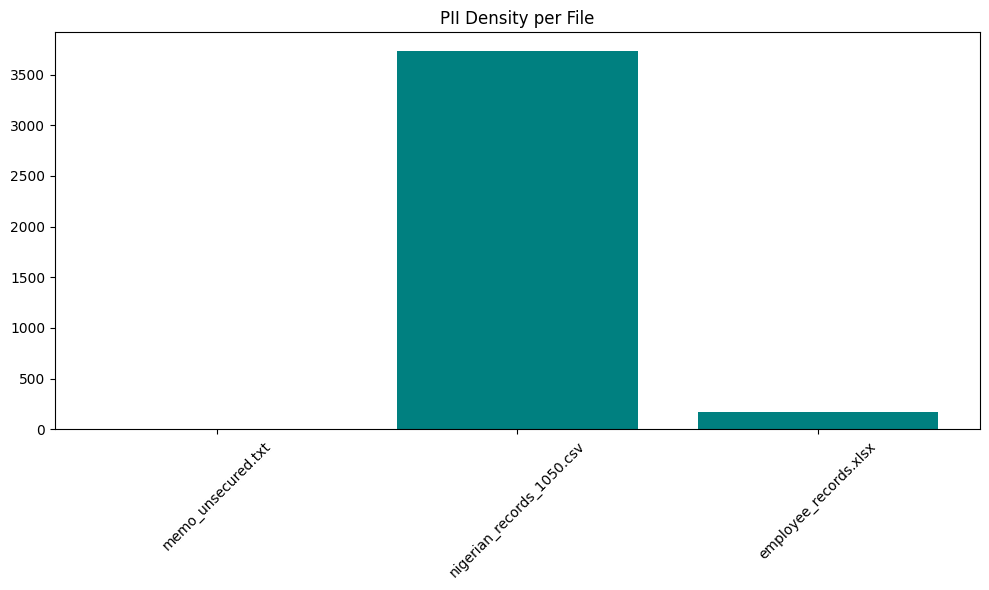

In [10]:
import pandas as pd
import re
import os
import random
import matplotlib.pyplot as plt

# --- CONFIGURATION ---
DIRECTORY_NAME = 'audit_directory'
REPORT_NAME = 'Compliance_Audit_Report.csv'

# 1. SETUP: Create the directory and synthetic data (Objective 3)
if not os.path.exists(DIRECTORY_NAME):
    os.makedirs(DIRECTORY_NAME)
    print(f"Created folder: {DIRECTORY_NAME}")

def generate_pii_record():
    nin = "".join([str(random.randint(0, 9)) for _ in range(11)])
    bvn = "".join([str(random.randint(0, 9)) for _ in range(11)])
    phone = f"0{random.choice([70, 80, 81, 90, 91])}{random.randint(10000000, 99999999)}"
    return nin, bvn, phone

# Create the 1,000+ record CSV
if not os.path.exists(f"{DIRECTORY_NAME}/nigerian_records_1050.csv"):
    data = []
    first = ["Abubakar", "Chidi", "Olumide", "Emeka", "Tunde", "Amina", "Chiamaka", "Zainab"]
    last = ["Adeyemi", "Okonkwo", "Bello", "Ojo", "Eze", "Balogun", "Danjuma", "Obi"]
    for i in range(1050):
        name = f"{random.choice(first)} {random.choice(last)}"
        nin, bvn, phone = generate_pii_record()
        data.append({"Name": name, "NIN": nin, "BVN": bvn, "Phone": phone})

    df = pd.DataFrame(data)
    df.to_csv(f"{DIRECTORY_NAME}/nigerian_records_1050.csv", index=False)
    df.head(50).to_excel(f"{DIRECTORY_NAME}/employee_records.xlsx", index=False)

    with open(f"{DIRECTORY_NAME}/memo_unsecured.txt", "w") as f:
        f.write(f"URGENT: New hire NIN is {generate_pii_record()[0]}")

    print("Synthetic test data generated successfully.")

# 2. SCANNING ENGINE: (Objective 2 & 4)
patterns = {
    "NIN": r'\b\d{11}\b',
    "BVN": r'\b\d{11}\b',
    "Phone": r'\b(070|080|081|090|091)\d{8}\b'
}

def scan_file(file_path):
    pii_counts = {"NIN": 0, "BVN": 0, "Phone": 0}
    ext = os.path.splitext(file_path)[1].lower()
    try:
        if ext == '.csv':
            text = pd.read_csv(file_path).astype(str).to_string()
        elif ext == '.xlsx':
            text = pd.read_excel(file_path).astype(str).to_string()
        elif ext == '.txt':
            with open(file_path, 'r') as f: text = f.read()
        else: return None

        for pii, pat in patterns.items():
            pii_counts[pii] = len(re.findall(pat, text))
        return pii_counts
    except: return None

# 3. GENERATE REPORT
report_data = []
for file in os.listdir(DIRECTORY_NAME):
    path = os.path.join(DIRECTORY_NAME, file)
    counts = scan_file(path)
    if counts:
        total = sum(counts.values())
        report_data.append({
            "File Name": file, "NIN": counts["NIN"], "BVN": counts["BVN"],
            "Phone": counts["Phone"], "Total PII": total,
            "Risk": "High" if total > 50 else "Medium"
        })

report_df = pd.DataFrame(report_data)
report_df.to_csv(REPORT_NAME, index=False)
print("\n--- COMPLIANCE AUDIT REPORT ---")
print(report_df)

# 4. VISUALIZE
plt.figure(figsize=(10,6))
plt.bar(report_df["File Name"], report_df["Total PII"], color='teal')
plt.title("PII Density per File")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()